In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [3]:
data_dir

'.\\datasets\\flower_photos'

In [4]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [5]:
from pathlib import Path
data_dir = Path("datasets/flower_photos/flower_photos")

In [6]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [7]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [8]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

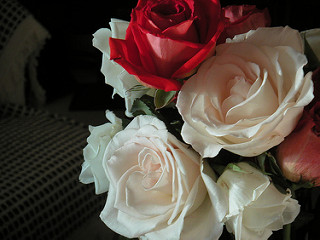

In [9]:
PIL.Image.open(str(roses[1]))

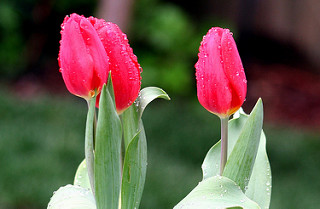

In [10]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [11]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [12]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [13]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [14]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [15]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(240, 179, 3)

In [16]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [17]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [18]:
X = np.array(X)
y = np.array(y)

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [20]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [21]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)         

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.4033 - loss: 1.4291
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.5745 - loss: 1.0669
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.6461 - loss: 0.8872
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step - accuracy: 0.7169 - loss: 0.7297
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.8100 - loss: 0.5275
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step - accuracy: 0.8950 - loss: 0.3247
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.9397 - loss: 0.1964
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.9517 - loss: 0.1746
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.9764 - loss: 0.0850
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step - accuracy: 0.9873 - loss: 0.0508
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.9876 - loss: 0.0433
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 14

In [22]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6329 - loss: 2.9055


[2.905463933944702, 0.6328976154327393]

In [23]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


array([[  3.1092508 ,  28.415648  ,  -1.1033894 , -17.531418  ,
         -8.859464  ],
       [ 10.859955  ,  -0.6842073 ,  -1.5408701 ,  -5.519536  ,
          3.4550345 ],
       [ -1.0069536 ,   5.541557  ,  16.546366  , -13.016093  ,
         -5.143532  ],
       ...,
       [  4.078386  ,  -0.9575256 , -11.118978  ,  11.3457365 ,
         12.347916  ],
       [  0.6317947 ,   0.71336544,   1.196678  ,  -3.161109  ,
         -4.27425   ],
       [  0.48971298, -13.874777  ,   2.7188962 ,   7.827672  ,
          4.7223268 ]], shape=(918, 5), dtype=float32)

In [24]:
score = tf.nn.softmax(predictions[0])
np.argmax(score)

np.int64(1)

In [25]:
y_test[0]

np.int64(1)

In [26]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(180,180, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


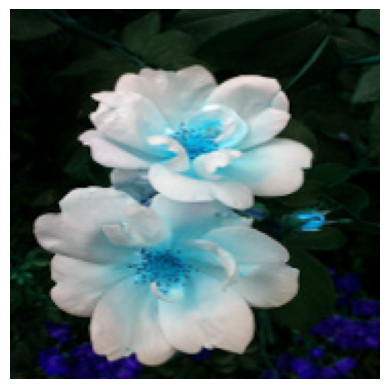

In [27]:
plt.axis('off')
plt.imshow(X[0])

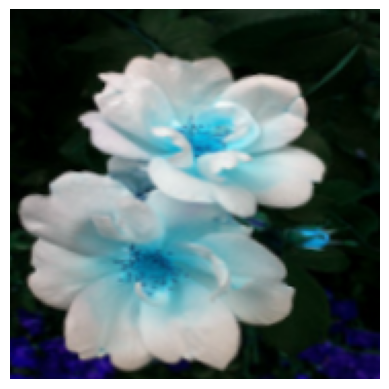

In [28]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

In [29]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)    

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 276ms/step - accuracy: 0.4426 - loss: 1.3020
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 281ms/step - accuracy: 0.5930 - loss: 1.0295
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.6537 - loss: 0.8896
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 230ms/step - accuracy: 0.6864 - loss: 0.8356
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 230ms/step - accuracy: 0.6962 - loss: 0.7951
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 230ms/step - accuracy: 0.7031 - loss: 0.7846
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.7235 - loss: 0.7337
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step - accuracy: 0.7326 - loss: 0.7007
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - accuracy: 0.7424 - loss: 0.6665
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - accuracy: 0.7475 - loss: 0.6427
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 234ms/step - accuracy: 0.7573 - loss: 0.6145
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 20

In [30]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7211 - loss: 0.9870


[0.986990213394165, 0.7211328744888306]